# Continuous Flow Matching (unconditional, QM9 / ZINC)

Pipeline: **train → sample → VUN**.

## Setup

In [1]:
import os

REPO = "flow-matching-molecules"
if not os.path.isdir(REPO):
    !git clone https://github.com/Nico-Conti/flow-matching-molecules.git
os.chdir(REPO if os.path.basename(os.getcwd()) != REPO else ".")

!pip install -q uv
!uv pip install --system -q -e .   # installs deps + the package from pyproject
import sys; sys.path.insert(0, os.path.abspath("src"))  # flat src/ layout
print("cwd:", os.getcwd())

Cloning into 'flow-matching-molecules'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 120 (delta 52), reused 117 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 1.35 MiB | 15.55 MiB/s, done.
Resolving deltas: 100% (52/52), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 26.3 MB/s eta 0:00:00
cwd: /content/flow-matching-molecules


In [2]:
import torch
import train, evaluate
print(torch.__version__, "cuda:", torch.cuda.is_available())

2.11.0+cu128 cuda: True


/usr/local/lib/python3.12/dist-packages/torch_molecule/generator/molgpt/modeling_molgpt.py:112: SyntaxWarning: invalid escape sequence '\['
  self.pattern = "(\[[^\]]+]|<|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"


## Reload a saved checkpoint (skip training)
Load a trained model without retraining. `which="final"` (default) loads the
last checkpoint; `which="best"` loads the lowest-val-loss checkpoint.

qm9_fm_best.pt:   0%|          | 0.00/61.0M [00:00<?, ?B/s]

loaded best checkpoint (epoch 191, best_val=0.7057426894864728)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/132040 [00:00<?, ? examples/s]

reconstructed split: 99030 train / 13204 test


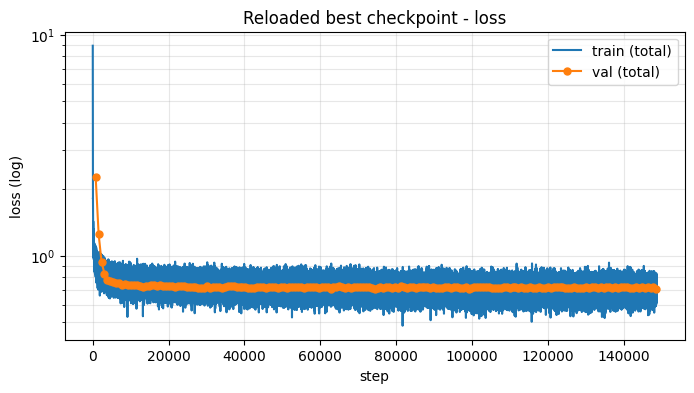

In [5]:
import os
import matplotlib.pyplot as plt
from checkpoint import repo_to_path, best_path, load_checkpoint, load_checkpoint_from_hf

repo  = "nico8771/qm9_fm"
which = "best"                      # "final" or "best"

local = repo_to_path(repo)
if which == "best":
    local = best_path(local)
fname = os.path.basename(local)

ck = load_checkpoint(local) if os.path.exists(local) else load_checkpoint_from_hf(repo, fname)

model        = ck["model"]
history      = ck["history"]
size_sampler = ck["size_sampler"]
train_smiles = ck["train_smiles"]
atom_vocab   = ck["atom_vocab"]
k_X, k_E     = ck["k_X"], ck["k_E"]
print(f"loaded {which} checkpoint (epoch {ck['epoch']}, best_val={ck['extra'].get('best_val')})")


from train import build_split

split_dataset = ck["extra"].get("dataset", "qm9")
split_seed    = ck["extra"].get("seed", 0)
split_subset  = None          # match the training call (QM9: None; ZINC 20k run: 20000)
sp = build_split(dataset=split_dataset, subset=split_subset, seed=split_seed,
                 val_frac=0.15, test_frac=0.10)
test_smiles = sp["test_smiles"]

assert sorted(sp["train_smiles"]) == sorted(train_smiles), \
    "split mismatch -- check split_subset/split_seed/val_frac/test_frac vs the training run"
print(f"reconstructed split: {len(sp['train_smiles'])} train / {len(test_smiles)} test")

# Plot loss from the reloaded history.
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"], label="train (total)", lw=1.5)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    spe = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * spe - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step"); plt.ylabel("loss (log)"); plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title(f"Reloaded {which} checkpoint - loss")
plt.show()


## QM9 — Train

In [ ]:
(model, history, size_sampler, train_smiles, atom_vocab,
 k_X, k_E, test_smiles) = train.train(
    epochs=100, batch_size=128, subset=None, dataset="qm9",
    push_repo="nico8771/qm9_flowmatching_2", save_every=10, lambda_E=5, grad_clip=1.0, method="fm_graph")

epoch 0 step 0 loss 8.7589 loss_x 2.4091 loss_e 1.2700 lr 5.00e-04
epoch 0 step 50 loss 1.7986 loss_x 0.3919 loss_e 0.2813 lr 5.00e-04
epoch 0 step 100 loss 1.3511 loss_x 0.3070 loss_e 0.2088 lr 5.00e-04
epoch 0 step 150 loss 1.1493 loss_x 0.2600 loss_e 0.1779 lr 5.00e-04
epoch 0 step 200 loss 1.0571 loss_x 0.2521 loss_e 0.1610 lr 5.00e-04
epoch 0 step 250 loss 1.0062 loss_x 0.2098 loss_e 0.1593 lr 5.00e-04
epoch 0 step 300 loss 1.0516 loss_x 0.2542 loss_e 0.1595 lr 5.00e-04
epoch 0 step 350 loss 1.0919 loss_x 0.2650 loss_e 0.1654 lr 5.00e-04
epoch 0 step 400 loss 1.0148 loss_x 0.2326 loss_e 0.1564 lr 5.00e-04
epoch 0 step 450 loss 0.9647 loss_x 0.2285 loss_e 0.1472 lr 5.00e-04
epoch 0 step 500 loss 1.0918 loss_x 0.2644 loss_e 0.1655 lr 5.00e-04
epoch 0 step 550 loss 0.8890 loss_x 0.2169 loss_e 0.1344 lr 5.00e-04
epoch 0 step 600 loss 0.9795 loss_x 0.2317 loss_e 0.1496 lr 5.00e-04
epoch 0 step 650 loss 0.8759 loss_x 0.1856 loss_e 0.1381 lr 5.00e-04
epoch 0 step 700 loss 0.9631 loss_x 0

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...m9_flowmatching_2_best.pt:   1%|1         |  571kB / 56.2MB            

  best saved -> checkpoints/qm9_flowmatching_2_best.pt (epoch 0) + pushed to nico8771/qm9_flowmatching_2
epoch 1 step 800 loss 0.8662 loss_x 0.2072 loss_e 0.1318 lr 5.00e-04
epoch 1 step 850 loss 0.8461 loss_x 0.1871 loss_e 0.1318 lr 5.00e-04
epoch 1 step 900 loss 0.8443 loss_x 0.1976 loss_e 0.1293 lr 5.00e-04
epoch 1 step 950 loss 0.9355 loss_x 0.2158 loss_e 0.1439 lr 5.00e-04
epoch 1 step 1000 loss 0.8956 loss_x 0.2031 loss_e 0.1385 lr 5.00e-04
epoch 1 step 1050 loss 0.9329 loss_x 0.2273 loss_e 0.1411 lr 5.00e-04
epoch 1 step 1100 loss 0.9983 loss_x 0.2341 loss_e 0.1528 lr 5.00e-04
epoch 1 step 1150 loss 0.7982 loss_x 0.1841 loss_e 0.1228 lr 5.00e-04
epoch 1 step 1200 loss 0.8112 loss_x 0.1874 loss_e 0.1248 lr 5.00e-04
epoch 1 step 1250 loss 0.8812 loss_x 0.2102 loss_e 0.1342 lr 5.00e-04
epoch 1 step 1300 loss 0.8121 loss_x 0.1864 loss_e 0.1252 lr 5.00e-04
epoch 1 step 1350 loss 0.8571 loss_x 0.1874 loss_e 0.1339 lr 5.00e-04
epoch 1 step 1400 loss 0.8921 loss_x 0.2067 loss_e 0.1371 l

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nts/qm9_flowmatching_2.pt: 100%|##########| 58.6MB / 58.6MB            

No files have been modified since last commit. Skipping to prevent empty commit.


  final saved -> checkpoints/qm9_flowmatching_2.pt (epoch 99) + pushed to nico8771/qm9_flowmatching_2


## QM9 — Loss curves


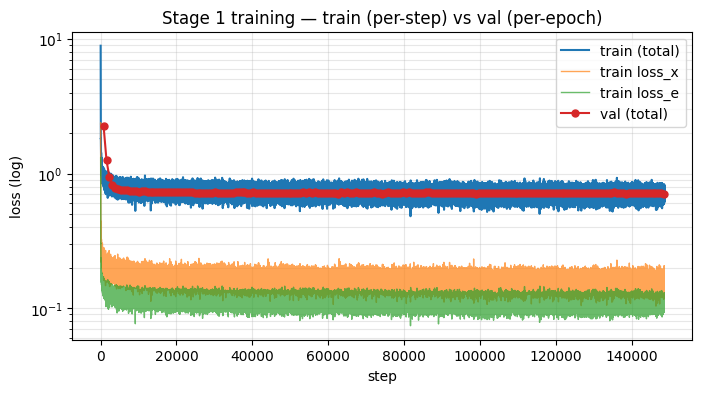

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"],   label="train (total)", lw=1.5)
plt.semilogy(history["step"], history["loss_x"], label="train loss_x", lw=1, alpha=0.7)
plt.semilogy(history["step"], history["loss_e"], label="train loss_e", lw=1, alpha=0.7)
# val_loss is per-epoch; anchor each marker at the last training step of its epoch.
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    steps_per_epoch = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Stage 1 training — train (per-step) vs val (per-epoch)")
plt.show()


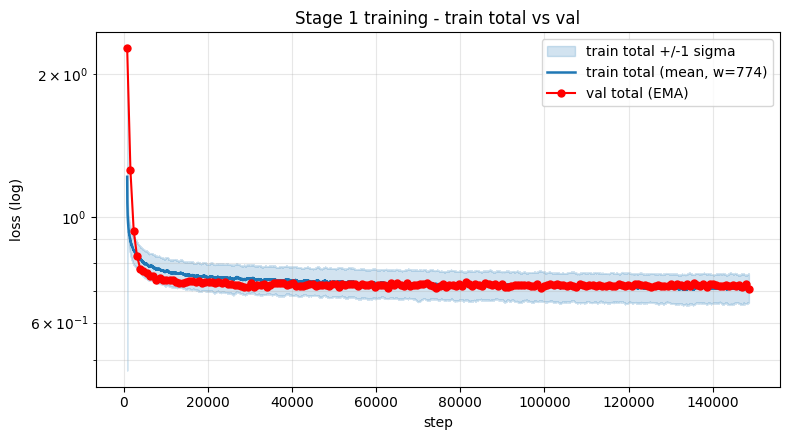

Final rolling-window values (w = 774 steps = 1 epoch)
  train total      loss=0.7099   std=0.0490 sigma/mu=6.90%
  val total (EMA)  loss=0.7057


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def rolling_stats(y, w):
    # Right-aligned rolling mean and std over window w; length len(y)-w+1.
    y = np.asarray(y, dtype=float)
    mean = np.convolve(y, np.ones(w) / w, mode="valid")
    mean_sq = np.convolve(y * y, np.ones(w) / w, mode="valid")
    var = np.clip(mean_sq - mean ** 2, 0.0, None)   # clip tiny FP negatives
    return mean, np.sqrt(var)

n_epochs = len(history["val_loss"])
steps_per_epoch = max(len(history["step"]) // max(n_epochs, 1), 1)
w = steps_per_epoch                          # 1-epoch smoothing window
steps = np.asarray(history["step"])
x_roll = steps[w - 1:]

mean_tot, std_tot = rolling_stats(history["loss"], w)

# --- Loss: train total (rolling mean +/-1 sigma) vs val --------------------
plt.figure(figsize=(8, 4.5))
plt.fill_between(x_roll, np.clip(mean_tot - std_tot, 1e-6, None), mean_tot +
std_tot,
                  color="C0", alpha=0.20, label="train total +/-1 sigma")
plt.semilogy(x_roll, mean_tot, color="C0", lw=1.8, label=f"train total (mean, w={w})")
if n_epochs > 0:
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", color="red", lw=1.5, ms=5,
                  label="val total (EMA)")
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.title("Stage 1 training - train total vs val")
plt.legend(loc="upper right")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Values (final rolling window) -----------------------------------------
cv = std_tot[-1] / mean_tot[-1] if mean_tot[-1] > 0 else float("nan")
print(f"Final rolling-window values (w = {w} steps = 1 epoch)")
print("=" * 52)
print(f"  {'train total':<16} loss={mean_tot[-1]:.4f}   std={std_tot[-1]:.4f} sigma/mu={cv:.2%}")
if n_epochs > 0:
    print(f"  {'val total (EMA)':<16} loss={history['val_loss'][-1]:.4f}")


## QM9 — Evaluate (V/U/N + FCD)


In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
out = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab, k_X, k_E,
                        n_samples=10000, batch=256, steps=100,
                        t_end=1, repair=False, fcd_ref=test_smiles,
                        device=device, method="fm_graph")
print(out)   # validity / uniqueness / novelty / repair_rate / fcd


{'validity': 0.9563, 'uniqueness': 0.9651782913311723, 'novelty': 0.581798483206934, 'n_generated': 10000, 'n_valid': 9563, 'n_unique': 9230, 'n_novel': 5370, 'repair_rate': 0.0, 'fcd': 1.1683723884930686}


## QM9 — Generated molecules (visual sample)


  0: CC1C=CC(C=O)N1C
  1: CC=CC1(C)C=CC1C
  2: CC1C=CCCCCC1
  3: CC1CC2C(C#N)OC12
  4: CC1N(CC=O)C1(C)C
  5: Nc1cc2c(cn1)OC2
  6: C=CC(O)OC
  7: CCC1=CCOCC1C
  8: O=CC12CC3CCC31C2
  9: CC#CCC
  10: CC1=NC=CON=CC1
  11: CC1CC(C)C(=O)O1


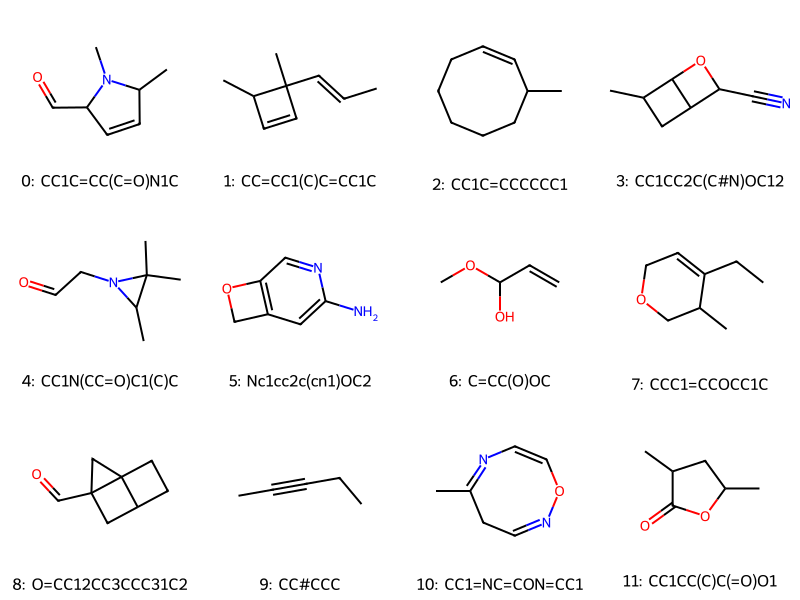

In [12]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from methods.fm_graph import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")


## ZINC — Train
Auto-resumes from the last checkpoint and pushes checkpoints to `push_repo`
(local path is implicit). `save_every` is the checkpoint cadence in epochs.

In [14]:
(model, history, size_sampler, train_smiles, atom_vocab,
 k_X, k_E, test_smiles) = train.train(
    dataset="zinc", epochs=5, batch_size=128, subset=None,
    push_repo="nico8771/zinc_fm_test", save_every=2, method="fm_graph")


epoch 0 step 0 loss 3.6734 loss_x 2.3892 loss_e 1.2843 lr 5.00e-04
epoch 0 step 50 loss 0.4911 loss_x 0.2845 loss_e 0.2066 lr 5.00e-04


KeyboardInterrupt: 

## ZINC — Loss curves


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"],   label="train (total)", lw=1.5)
plt.semilogy(history["step"], history["loss_x"], label="train loss_x", lw=1, alpha=0.7)
plt.semilogy(history["step"], history["loss_e"], label="train loss_e", lw=1, alpha=0.7)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    steps_per_epoch = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Stage 1 ZINC training — train (per-step) vs val (per-epoch)")
plt.show()


## ZINC — Evaluate (V/U/N)


In [ ]:
# ZINC V/U/N (VUN-only). To also get FCD here, reload with split_subset=20000
# in the reload cell (or reuse the test set returned by the ZINC train cell) and
# pass it as the FCD reference, mirroring the QM9 cell above.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vun = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab,
                        k_X, k_E, n_samples=1000, batch=256, steps=100,
                        device=device, method="fm_graph")
print(vun)


## ZINC — Generated molecules (visual sample)


In [ ]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from methods.fm_graph import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")
